# Housing Price Prediction Experiment

**Goal:** Predict house prices using features like area, bedrooms, bathrooms, etc.

**The 8 Steps:**
1. Load → 2. Validate → 3. EDA → 4. Preprocess → 5. Split → 6. Train → 7. Evaluate → 8. Save

## Step 1: Load the CSV

In [81]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_csv, validate_dataframe, split_data
from src.preprocessing import handle_missing_values, encode_categorical, scale_features
from src.model import train_regressor, evaluate_regressor, save_model, save_metrics
from src.utils import quick_eda, plot_correlation_matrix

%matplotlib inline
sns.set_style("whitegrid")

# Load from data/raw/
df = load_csv("housing.csv")
df.head()

Loaded housing.csv: 49 rows, 7 columns


,area,bedrooms,bathrooms,stories,parking,furnishing,price
0,7420,4,2,3,2,furnished,13300000
1,8960,4,4,4,3,furnished,12250000
2,9960,3,2,2,2,semi-furnished,12250000
3,7500,4,2,2,3,furnished,12215000
4,7420,4,1,2,2,furnished,11410000


## Step 2: Validate — is the data OK?

In [82]:
report = validate_dataframe(df, required_columns=["area", "bedrooms", "price"])
print(f"Valid: {report['is_valid']}")
print(f"Rows: {report['rows']}, Columns: {report['columns']}")
print(f"Issues: {report['issues'] if report['issues'] else 'None'}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Valid: True
Rows: 49, Columns: 7
Issues: None

Column types:
area          int64
bedrooms      int64
bathrooms     int64
stories       int64
parking       int64
furnishing      str
price         int64
dtype: object

Missing values:
area          0
bedrooms      0
bathrooms     0
stories       0
parking       0
furnishing    0
price         0
dtype: int64


## Step 3: EDA — understand the data

In [83]:
# Quick stats
quick_eda(df, title="Housing Data")


  EDA: Housing Data
Shape: (49, 7)

Column types:
int64    6
str      1
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)

Numeric summary:
           area  bedrooms  bathrooms  stories  parking        price
count     49.00     49.00      49.00    49.00    49.00        49.00
mean    5999.84      2.98       1.49     1.76     1.02   7928387.76
std     2500.70      0.72       0.71     0.83     0.95   2248874.31
min     1650.00      2.00       1.00     1.00     0.00   3360000.00
25%     4000.00      3.00       1.00     1.00     0.00   6615000.00
50%     6200.00      3.00       1.00     2.00     1.00   7560000.00
75%     7440.00      3.00       2.00     2.00     2.00   9240000.00
max    16200.00      5.00       4.00     4.00     3.00  13300000.00


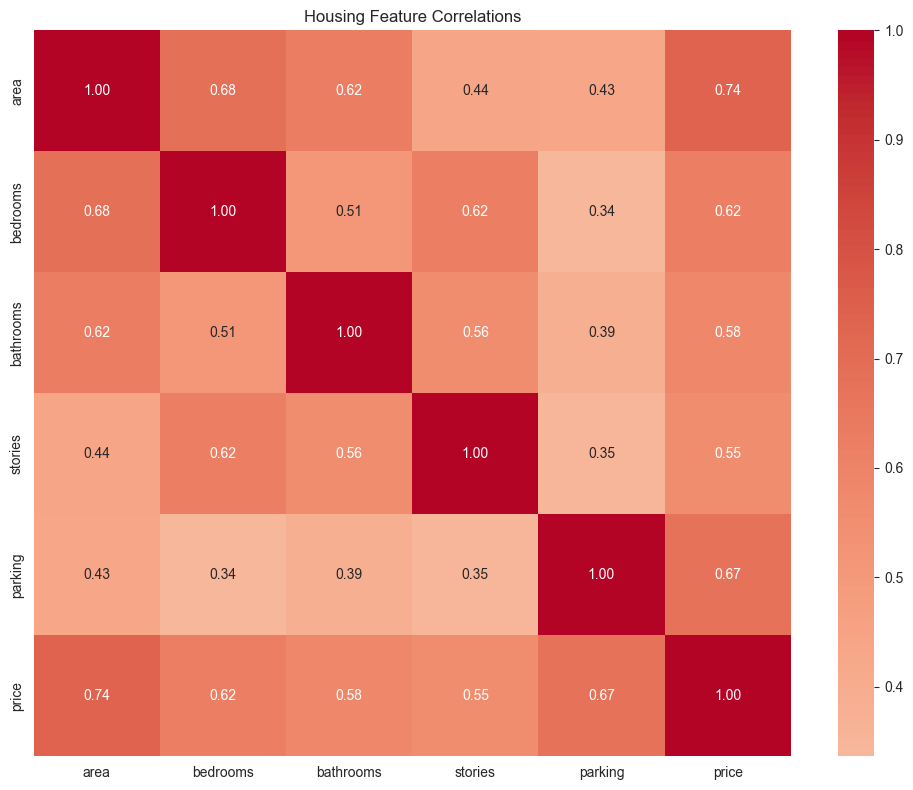

In [84]:
# Correlation heatmap — which features relate to price?
fig = plot_correlation_matrix(df, title="Housing Feature Correlations")
plt.show()

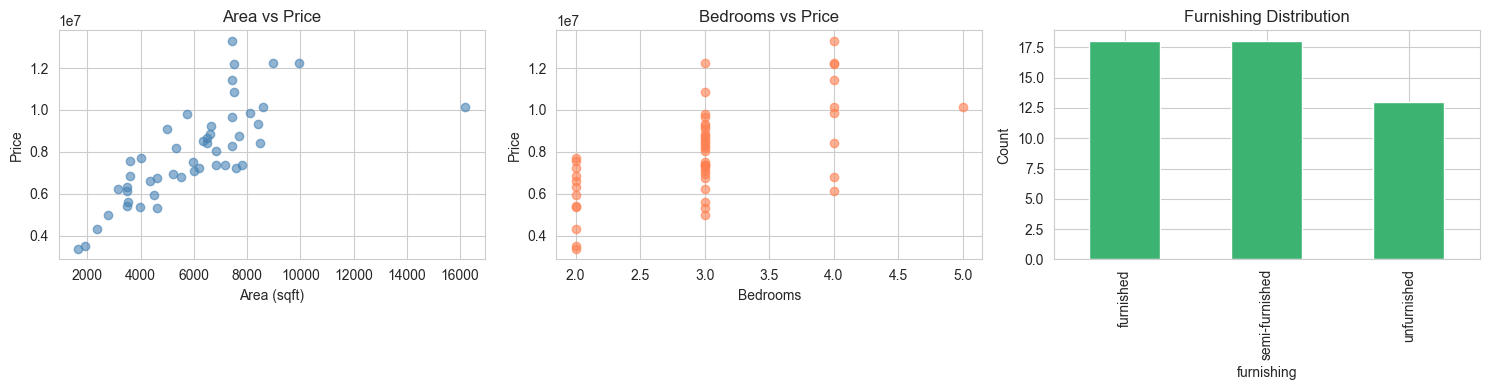

In [85]:
# Scatter: Area vs Price — is bigger house = higher price?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['area'], df['price'], alpha=0.6, color='steelblue')
axes[0].set_xlabel('Area (sqft)')
axes[0].set_ylabel('Price')
axes[0].set_title('Area vs Price')

axes[1].scatter(df['bedrooms'], df['price'], alpha=0.6, color='coral')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Price')
axes[1].set_title('Bedrooms vs Price')

df['furnishing'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Furnishing Distribution')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 4: Preprocess — clean the data

- Fill any missing values with median
- Convert "furnished" / "semi-furnished" / "unfurnished" → numbers (0, 1, 2)

In [86]:
# Fill missing values
df_clean = handle_missing_values(df, strategy="median")

# Convert text column to numbers
df_encoded = encode_categorical(df_clean, columns=["furnishing"], method="label")

print("Before → After:")
print(f"  'furnished'      → 0")
print(f"  'semi-furnished' → 1")
print(f"  'unfurnished'    → 2")
print()
df_encoded.head()

Before → After:
  'furnished'      → 0
  'semi-furnished' → 1
  'unfurnished'    → 2



,area,bedrooms,bathrooms,stories,parking,furnishing,price
0,7420,4,2,3,2,0,13300000
1,8960,4,4,4,3,0,12250000
2,9960,3,2,2,2,1,12250000
3,7500,4,2,2,3,0,12215000
4,7420,4,1,2,2,0,11410000


In [87]:
# Save the cleaned data to data/processed/ — so you don't have to clean it again
df_encoded.to_csv("../data/processed/housing_cleaned.csv", index=False)

print("✅ Saved cleaned data → data/processed/housing_cleaned.csv")
print(f"   Rows: {len(df_encoded)}, Columns: {list(df_encoded.columns)}")
print()
print("📁 What's in each folder now:")
print("   data/raw/housing.csv                ← original messy data (never touch)")
print("   data/processed/housing_cleaned.csv   ← cleaned, ready to use")
print()
print("Next time skip cleaning and just do:")
print('   df = pd.read_csv("data/processed/housing_cleaned.csv")')

✅ Saved cleaned data → data/processed/housing_cleaned.csv
   Rows: 49, Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'furnishing', 'price']

📁 What's in each folder now:
   data/raw/housing.csv                ← original messy data (never touch)
   data/processed/housing_cleaned.csv   ← cleaned, ready to use

Next time skip cleaning and just do:
   df = pd.read_csv("data/processed/housing_cleaned.csv")


## Step 5: Split — 80% train, 20% test

In [88]:
# Target = "price" (what we predict)
# Features = everything else (area, bedrooms, etc.)
X_train, X_test, y_train, y_test = split_data(df_encoded, target_column="price")

print(f"Features: {list(X_train.columns)}")
print(f"Target: price")

Train: 39 rows | Test: 10 rows
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'furnishing']
Target: price


## Step 6: Train — try different models

Let's compare **Linear Regression** vs **Random Forest** to see which predicts better.

In [89]:
# Model 1: Linear Regression
print("=" * 40)
print("  MODEL 1: Linear Regression")
print("=" * 40)
model_lr = train_regressor(X_train, y_train, model_name="linear_regression")
metrics_lr = evaluate_regressor(model_lr, X_test, y_test)

  MODEL 1: Linear Regression
Trained linear_regression regressor on 39 samples
R²: 0.4184 | MAE: 1044560.6568 | RMSE: 1278214.1079


In [90]:
# Model 2: Random Forest
print("=" * 40)
print("  MODEL 2: Random Forest")
print("=" * 40)
model_rf = train_regressor(X_train, y_train, model_name="random_forest", n_estimators=100, random_state=42)
metrics_rf = evaluate_regressor(model_rf, X_test, y_test)

  MODEL 2: Random Forest
Trained random_forest regressor on 39 samples
R²: 0.1892 | MAE: 1325558.0000 | RMSE: 1509169.5371


## Step 7: Compare — which model is better?

      Linear Regression  Random Forest
r2         4.183671e-01   1.891924e-01
mae        1.044561e+06   1.325558e+06
rmse       1.278214e+06   1.509170e+06


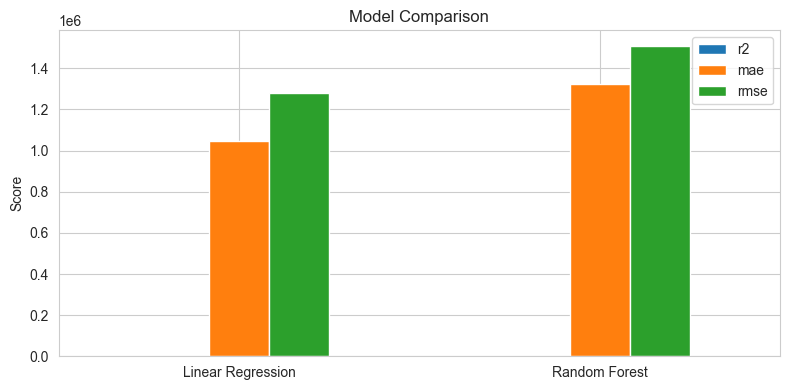


🏆 Winner: Linear Regression


In [91]:
# Side-by-side comparison
comparison = pd.DataFrame({
    "Linear Regression": metrics_lr,
    "Random Forest": metrics_rf
})
print(comparison.to_string())

# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
comparison.T.plot(kind="bar", ax=ax)
ax.set_title("Model Comparison")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Pick the winner
best = "Linear Regression" if metrics_lr["r2"] > metrics_rf["r2"] else "Random Forest"
print(f"\n🏆 Winner: {best}")

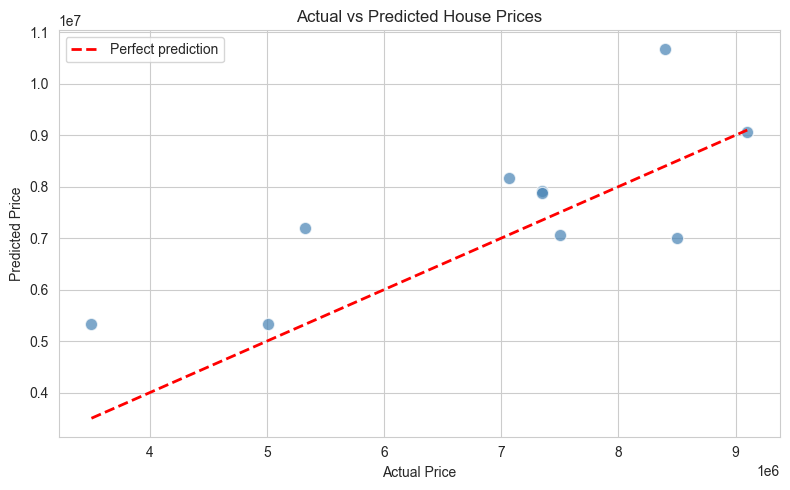

In [92]:
# Actual vs Predicted — see how close the predictions are
best_model = model_lr if metrics_lr["r2"] > metrics_rf["r2"] else model_rf
y_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, y_pred, alpha=0.7, s=80, color='steelblue', edgecolor='white')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title('Actual vs Predicted House Prices')
ax.legend()
plt.tight_layout()
plt.show()

## Step 8: Save the best model

In [93]:
# Save the winning model and its metrics
save_model(best_model, "housing_best")
save_metrics(metrics_lr if metrics_lr["r2"] > metrics_rf["r2"] else metrics_rf, "housing_best")

print("\n✅ Done! Your model is saved in models/housing_best.joblib")
print("   Metrics saved in outputs/housing_best_metrics.json")

Model saved to /Users/araz/Documents/3.DEV WORKS/project-works/Pro ML Setup/models/housing_best.joblib
Metrics saved to /Users/araz/Documents/3.DEV WORKS/project-works/Pro ML Setup/outputs/housing_best_metrics.json

✅ Done! Your model is saved in models/housing_best.joblib
   Metrics saved in outputs/housing_best_metrics.json


## 🧪 Your Experiments

Try changing things below and re-run to see what happens:
- Change `test_size` in `split_data()` (try 0.3 or 0.1)
- Change `n_estimators` in Random Forest (try 200, 500)
- Try `scale_features()` before training — does it help?
- Remove a column and see if accuracy changes

In [94]:
### EXPERIMENT 1: Scale features first — does it help?
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

model_lr_scaled = train_regressor(X_train_scaled, y_train, model_name="linear_regression")
metrics_lr_scaled = evaluate_regressor(model_lr_scaled, X_test_scaled, y_test)

model_rf_scaled = train_regressor(X_train_scaled, y_train, model_name="random_forest", n_estimators=100, random_state=42)
metrics_rf_scaled = evaluate_regressor(model_rf_scaled, X_test_scaled, y_test)

print("📊 EXPERIMENT 1: With Feature Scaling")
print(f"  Linear Regression R² : {metrics_lr['r2']:.3f} → {metrics_lr_scaled['r2']:.3f}")
print(f"  Random Forest R²     : {metrics_rf['r2']:.3f} → {metrics_rf_scaled['r2']:.3f}")


### EXPERIMENT 2: More trees in Random Forest (100 → 500)
model_rf_500 = train_regressor(X_train, y_train, model_name="random_forest", n_estimators=500, random_state=42)
metrics_rf_500 = evaluate_regressor(model_rf_500, X_test, y_test)

print(f"\n📊 EXPERIMENT 2: Random Forest with 500 trees")
print(f"  R² with 100 trees: {metrics_rf['r2']:.3f}")
print(f"  R² with 500 trees: {metrics_rf_500['r2']:.3f}")


### EXPERIMENT 3: Different train/test split (80/20 → 70/30)
X_train_70, X_test_30, y_train_70, y_test_30 = split_data(df_encoded, target_column="price", test_size=0.3)

model_lr_70 = train_regressor(X_train_70, y_train_70, model_name="linear_regression")
metrics_lr_70 = evaluate_regressor(model_lr_70, X_test_30, y_test_30)

print(f"\n📊 EXPERIMENT 3: 70/30 split instead of 80/20")
print(f"  LR R² with 80/20: {metrics_lr['r2']:.3f}")
print(f"  LR R² with 70/30: {metrics_lr_70['r2']:.3f}")


### EXPERIMENT 4: Remove weak features — keep only the best ones
strong_features = ["area", "bathrooms", "stories", "parking"]
X_train_slim = X_train[strong_features]
X_test_slim = X_test[strong_features]

model_lr_slim = train_regressor(X_train_slim, y_train, model_name="linear_regression")
metrics_lr_slim = evaluate_regressor(model_lr_slim, X_test_slim, y_test)

print(f"\n📊 EXPERIMENT 4: Only strong features {strong_features}")
print(f"  LR R² all features   : {metrics_lr['r2']:.3f}")
print(f"  LR R² strong features: {metrics_lr_slim['r2']:.3f}")


### SUMMARY TABLE
print("\n" + "=" * 55)
print("  📋 EXPERIMENT SUMMARY")
print("=" * 55)
results = pd.DataFrame({
    "Experiment": [
        "Original LR", "Original RF",
        "Scaled LR", "Scaled RF",
        "RF 500 trees", "70/30 split LR",
        "Strong features LR"
    ],
    "R2": [
        metrics_lr["r2"], metrics_rf["r2"],
        metrics_lr_scaled["r2"], metrics_rf_scaled["r2"],
        metrics_rf_500["r2"], metrics_lr_70["r2"],
        metrics_lr_slim["r2"]
    ],
    "MAE": [
        metrics_lr["mae"], metrics_rf["mae"],
        metrics_lr_scaled["mae"], metrics_rf_scaled["mae"],
        metrics_rf_500["mae"], metrics_lr_70["mae"],
        metrics_lr_slim["mae"]
    ]
})
results = results.sort_values("R2", ascending=False)
print(results.to_string(index=False))
print(f"\n🏆 Best experiment: {results.iloc[0]['Experiment']}")

Trained linear_regression regressor on 39 samples
R²: 0.4184 | MAE: 1044560.6568 | RMSE: 1278214.1079
Trained random_forest regressor on 39 samples
R²: 0.1836 | MAE: 1330424.0000 | RMSE: 1514378.5094
📊 EXPERIMENT 1: With Feature Scaling
  Linear Regression R² : 0.418 → 0.418
  Random Forest R²     : 0.189 → 0.184
Trained random_forest regressor on 39 samples
R²: 0.1549 | MAE: 1342258.6000 | RMSE: 1540741.5217

📊 EXPERIMENT 2: Random Forest with 500 trees
  R² with 100 trees: 0.189
  R² with 500 trees: 0.155
Train: 34 rows | Test: 15 rows
Trained linear_regression regressor on 34 samples
R²: 0.6274 | MAE: 1079663.0688 | RMSE: 1371460.2070

📊 EXPERIMENT 3: 70/30 split instead of 80/20
  LR R² with 80/20: 0.418
  LR R² with 70/30: 0.627
Trained linear_regression regressor on 39 samples
R²: 0.4541 | MAE: 1080570.4063 | RMSE: 1238348.6658

📊 EXPERIMENT 4: Only strong features ['area', 'bathrooms', 'stories', 'parking']
  LR R² all features   : 0.418
  LR R² strong features: 0.454

  📋 EXPER